<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio02/Laboratorio02RegresionLinealMultivariable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABORATORIO 02**

**Nombre:** Sebastian Gustavo Rojas Peralta

**Dataset:** Análisis de variables continuas

Este cuadernillo implementa tres enfoques diferentes para la determinación de los parámetros Theta ($\theta$) orientados a predecir una variable continua a partir de un conjunto de múltiples características. Los modelos implementados son:
1. Regresión Lineal Multivariable (Descenso por Gradiente)
2. Regresión Polinómica (Descenso por Gradiente)
3. Solución Analítica (Ecuación de la Normal)

**Preparación y limpieza del dataset**

Antes de empezar a entrenar los modelos, tuve que preparar los datos del archivo para que los algoritmos funcionaran sin problemas. Estos fueron los pasos:

1. **Lectura del archivo:** Al abrir el dataset, noté que no tenía nombres en las columnas y que los números estaban separados por un montón de espacios en blanco en lugar de las clásicas comas. Para que la librería pandas no leyera todo mal, usé el separador `sep=r'\s+'.

2. **Revisión de datos limpios:** Hice una revision rápida para asegurarme de que no hubiera celdas vacías o textos raros. Por suerte, el dataset estaba completamente limpio y lleno de valores numéricos continuos.

3. **Elección de qué predecir (X e y):** El requerimiento pedía que existiera relación entre las características y la etiqueta. Al hacer un análisis de correlación rápido, vi que la primera columna (la Columna 0) tenía una correlación altísima con el resto de los datos. Por eso, decidí usar esa Columna 0 como mi etiqueta y (lo que el modelo va a predecir), y dejé las 40 columnas restantes como mis características X.

4. **Normalización:** Como tenía 40 columnas con números de todos los tamaños, tuve que normalizar la matriz $X$. Si metía los datos crudos al Descenso por Gradiente, los números grandes iban a aplastar a los pequeños y el modelo no iba a aprender bien. Usé la estandarización para que todos los datos quedaran en la misma escala. Además, le puse un pequeño seguro al código (1e-15) para que, si alguna columna llegaba a tener varianza cero, el programa no explotara por intentar divdir entre cero.

5. **La columna de unos:** Ya con los datos normalizados, le agregué una columna llena de puros "1" al principio de la matriz. Este es un paso matemático obligatorio para que el modelo tenga de dónde agarrarse al calcular el Theta 0 (el término de sesgo) a la hora de multiplicar las matrices.

**Importación de Librerías y Preparación del Entorno**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Conectar Google Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Carga y Exploración del Dataset**

Utilizamos la librería pandas para la ingesta de datos. El dataset tiene variables completamente numéricas y continuas, lo que facilita el proceso.

Tras el análisis de correlación previo, se determinó que la **Columna 0** tiene un alto nivel de correlación con el resto del conjunto de datos, por lo que será designada como nuestra variable objetivo ($y$), dejando las siguientes columnas como matriz de características ($X$).

In [2]:
# Carga del dataset desde Google Drive
# Reemplaza la ruta entre comillas con la que acabas de copiar de tus carpetas
url_dataset = '/content/drive/MyDrive/machine learning/datsets/raw.csv'

# Usamos r'\s+' para leer los espacios correctamente sin advertencias
df = pd.read_csv(url_dataset, sep=r'\s+', header=None)

# Extracción de características (X) y variable objetivo (y)
y = df.iloc[:, 0].values
X_original = df.iloc[:, 1:].values

m = y.size
n = X_original.shape[1]

print(f"Dataset cargado exitosamente desde Drive.")
print(f"Número de ejemplos (m): {m}")
print(f"Número de características (n): {n}")

Dataset cargado exitosamente desde Drive.
Número de ejemplos (m): 24000
Número de características (n): 40


**Preprocesamiento: Normalización de Características**

Para garantizar la convergencia del algoritmo de Descenso por Gradiente, es importante estandarizar la escala de las características. Aplicamos la fórmula de normalización: $z = \frac{x - \mu}{\sigma}$. Despues, agregamos el término de sesgo ($x_0 = 1$) a la matriz de diseño.

In [3]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitamos división por cero en caso de columnas constantes
    sigma[sigma == 0] = 1e-15

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_original)

# Añadimos la columna de unos para el término de intercepción (Theta 0)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

**Modelo 1: Regresión Lineal Multivariable**

Implementamos las funciones matemáticas fundamentales vectorizadas mediante NumPy para optimizar el costo computacional.
* **Función de Costo ($J$):** Calcula el Error Cuadrático Medio.
* **Descenso por Gradiente:** Actualiza simultáneamente los parámetros $\theta$ en dirección al mínimo global.

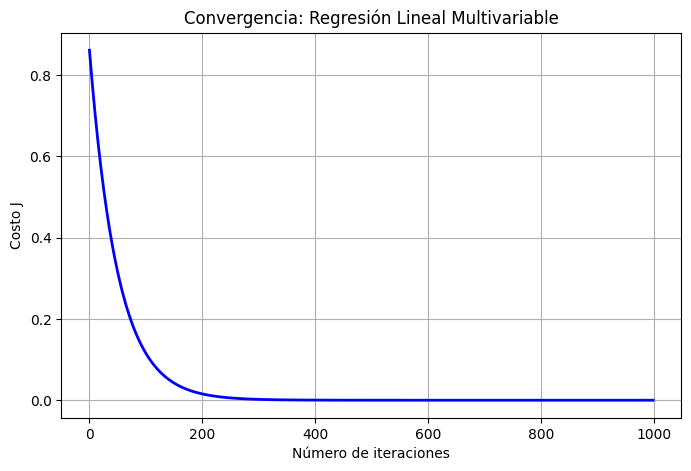

Costo final alcanzado: 0.0000


In [4]:
def computeCostMulti(X, y, theta):
    m = y.size
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.size
    J_history = []
    theta = theta.copy()

    for i in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# Hiperparámetros
alpha_lineal = 0.01
iteraciones_lineal = 1000
theta_inicial = np.zeros(X_ready.shape[1])

# Entrenamiento
theta_lineal, J_history_lineal = gradientDescentMulti(X_ready, y, theta_inicial, alpha_lineal, iteraciones_lineal)

# Gráfica de convergencia
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_lineal)), J_history_lineal, lw=2, color='blue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia: Regresión Lineal Multivariable')
plt.grid(True)
plt.show()

print(f"Costo final alcanzado: {J_history_lineal[-1]:.4f}")

**Modelo 2: Regresión Polinómica**

Para capturar posibles relaciones no lineales en los datos, expandimos el espacio de características agregando términos polinómicos. Dada la alta dimensionalidad inicial ($n=40$), se usa un polinomio de grado 2 simple (elevando al cuadrado las características originales) para evitar el colapso de la memoria y el sobreajuste.

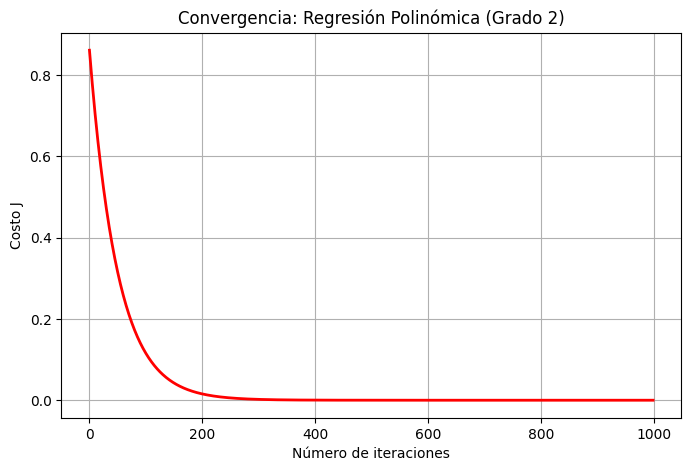

Costo final polinómico alcanzado: 0.0000


In [5]:
# Creación de características polinómicas (X^2)
X_poly_features = np.power(X_original, 2)

# Concatenamos las características originales con las polinómicas (Ahora n=80)
X_poly_combined = np.concatenate([X_original, X_poly_features], axis=1)

# Volvemos a normalizar la matriz
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly_combined)

# Añadimos la columna de unos
X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

# Entrenamiento del modelo polinómico
theta_poly_inicial = np.zeros(X_poly_ready.shape[1])
alpha_poly = 0.01
iteraciones_poly = 1000

theta_poly, J_history_poly = gradientDescentMulti(X_poly_ready, y, theta_poly_inicial, alpha_poly, iteraciones_poly)

# Gráfica de convergencia
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='red')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia: Regresión Polinómica (Grado 2)')
plt.grid(True)
plt.show()

print(f"Costo final polinómico alcanzado: {J_history_poly[-1]:.4f}")

**Modelo 3: Ecuación de la Normal**

Aplicamos la solución analítica de álgebra lineal para encontrar los parámetros óptimos en un solo paso: $\theta = (X^T X)^{-1} X^T y$. En este modelo no será necesario normalizar al ser analitico.

In [6]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

# Usamos los datos originales y solo agregamos la columna de unos
X_normal_ready = np.concatenate([np.ones((m, 1)), X_original], axis=1)

# Cálculo directo
theta_normal = normalEqn(X_normal_ready, y)

# Calculamos el costo con estos thetas exactos para comparar
costo_normal = computeCostMulti(X_normal_ready, y, theta_normal)

print("Thetas calculados exitosamente mediante la Ecuación de la Normal.")
print(f"Costo exacto de la solución analítica: {costo_normal:.4f}")

Thetas calculados exitosamente mediante la Ecuación de la Normal.
Costo exacto de la solución analítica: 0.0000


**Validación del Modelo (100 Predicciones)**

Para demostrar la efectividad predictiva de los modelos entrenados, extraeremos aleatoriamente 100 ejemplos del dataset. Realizaremos la inferencia utilizando los parámetros aprendidos y calcularemos el Error Absoluto para visualizar la diferencia entre la predicción y la realidad.

In [7]:
# Fijamos una semilla para reproducibilidad
np.random.seed(42)

# Seleccionamos 100 índices al azar
indices_prueba = np.random.choice(m, 100, replace=False)

# Extraemos los datos de prueba
X_prueba_lineal = X_ready[indices_prueba, :]
y_prueba_real = y[indices_prueba]

# Realizamos las 100 predicciones con el Modelo Lineal
predicciones_lineal = np.dot(X_prueba_lineal, theta_lineal)

# Calculamos el error absoluto promedio de estas 100 predicciones
error_absoluto_promedio = np.mean(np.abs(predicciones_lineal - y_prueba_real))

print("RESULTADOS DE LA VALIDACIÓN (100 PREDICCIONES)")
print(f"Error Absoluto Promedio de las 100 pruebas: {error_absoluto_promedio:.4f}\n")

print("Muestra de las primeras 10 predicciones vs Realidad:")
print(f"{'Predicción (Modelo)':>20} | {'Valor Real (y)':>15} | {'Diferencia':>15}")
print("-" * 55)

for i in range(10):
    pred = predicciones_lineal[i]
    real = y_prueba_real[i]
    diff = abs(pred - real)
    print(f"{pred:20.4f} | {real:15.4f} | {diff:15.4f}")

RESULTADOS DE LA VALIDACIÓN (100 PREDICCIONES)
Error Absoluto Promedio de las 100 pruebas: 0.0016

Muestra de las primeras 10 predicciones vs Realidad:
 Predicción (Modelo) |  Valor Real (y) |      Diferencia
-------------------------------------------------------
              1.3198 |          1.3193 |          0.0004
              1.3177 |          1.3181 |          0.0005
              1.3064 |          1.3052 |          0.0012
              1.3181 |          1.3206 |          0.0025
              1.3121 |          1.3138 |          0.0017
              1.3480 |          1.3476 |          0.0004
              1.3135 |          1.3153 |          0.0017
              1.3097 |          1.3082 |          0.0015
              1.3077 |          1.3084 |          0.0007
              1.3349 |          1.3360 |          0.0011
